In [ ]:
import os, platform, torch

# Рабочая директория в зависимости от среды
if platform.system() == 'Darwin':
    REPO_DIR = '/Users/amir/sciml/diffusion_data_assimilation'
else:
    REPO_DIR = '/home'

os.chdir(REPO_DIR)
print(f"cwd: {os.getcwd()}")

device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available()
          else 'cpu')
print(f"device: {device}")

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch
from diffusers.training_utils import EMAModel
from diffusers import UNet2DModel

from sampler import Sampler
from utils import NpyImageDataset
from utils import add_noise, channel_normalize, channel_denormalize

In [3]:
channel_mean = [0.1382167, 0.1816227]
channel_std = [0.32978467, 0.51380478]

In [4]:
model = UNet2DModel(
        sample_size=(320, 256),
        in_channels=4,
        out_channels=2,
        layers_per_block=2,
        block_out_channels=(64, 128, 256, 512, 512),
        down_block_types=(
            "DownBlock2D", "DownBlock2D", "DownBlock2D", 
            "AttnDownBlock2D", "DownBlock2D",
        ),
        up_block_types=(
            "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", 
            "UpBlock2D", "UpBlock2D",
        ),
    )

In [ ]:
# device определён в первой ячейке (cuda / mps / cpu)
model.to(device)
ema = EMAModel(model.parameters())

# map_location — обязателен для загрузки CUDA-чекпойнта на MPS/CPU
ema_state = torch.load(
    "/home/checkpoints/best_model/ema_state.pth",
    map_location=device,
    weights_only=True,
)

ema.load_state_dict(ema_state)
ema.copy_to(model.parameters())

model.to(device)
model.eval();

## Uncoditional Samples

In [6]:
sampler = Sampler(model=model, noise_func=add_noise)

In [7]:
unconditional_samples = sampler.sample_no_condition(100, 30)
unconditional_samples = channel_denormalize(unconditional_samples, channel_mean=channel_mean, channel_std=channel_std)

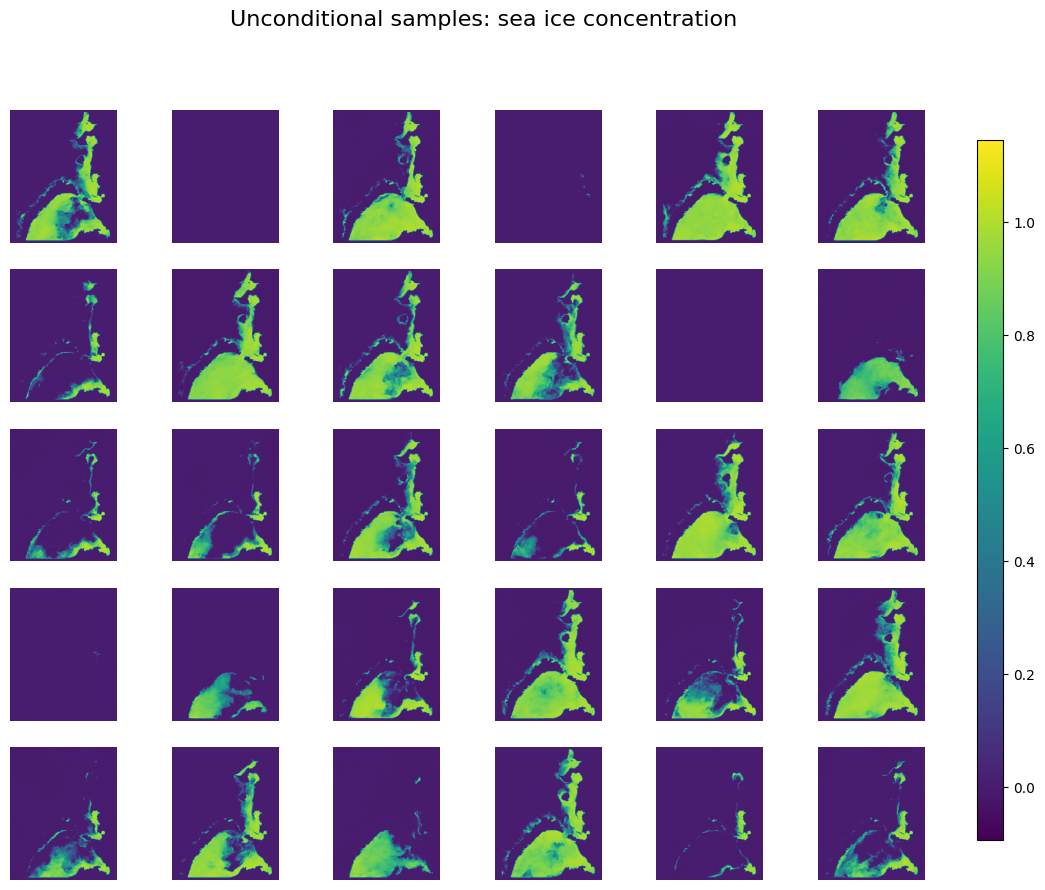

In [8]:
rows, cols = 5, 6
n = rows * cols

imgs = [unconditional_samples[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2))
axes = axes.flatten()
fig.suptitle("Unconditional samples: sea ice concentration", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis') 
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.85) 
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
plt.show()

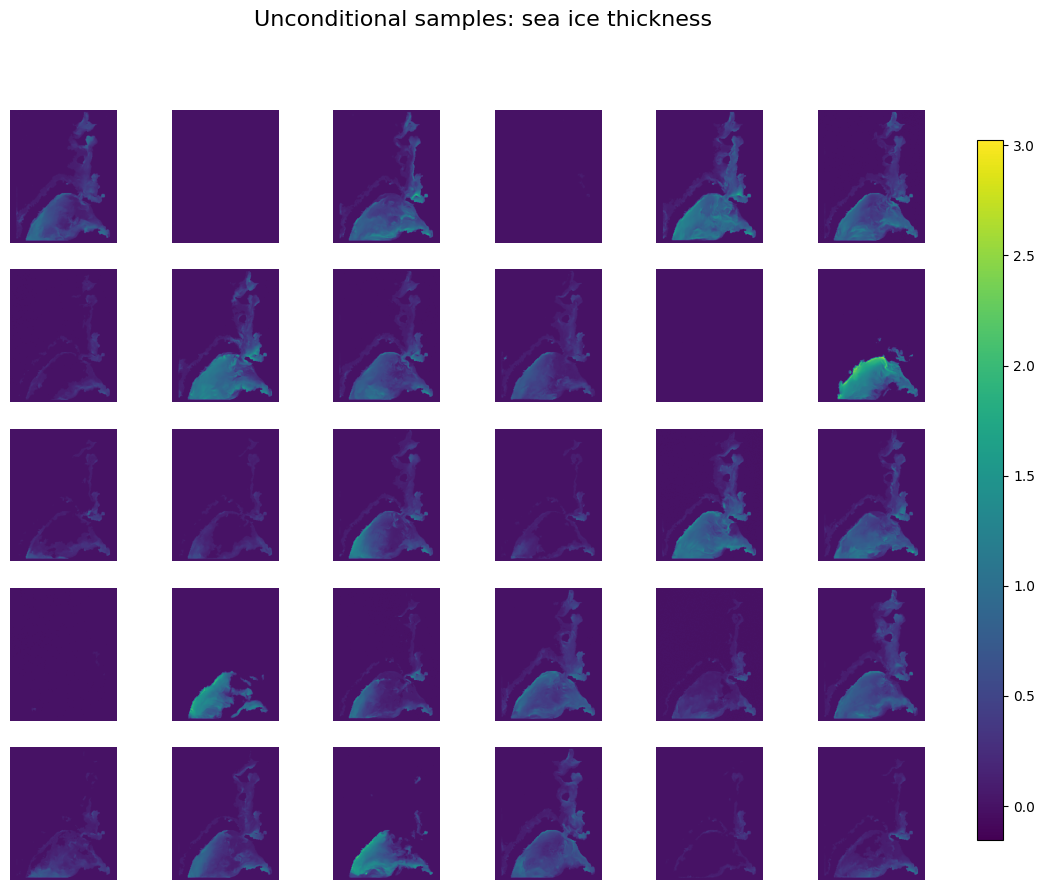

In [9]:
rows, cols = 5, 6
n = rows * cols

imgs = [unconditional_samples[i][1].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2))
axes = axes.flatten()
fig.suptitle("Unconditional samples: sea ice thickness", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis') 
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.85) 
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
plt.show()

## Conditioning on Satellite data

In [10]:
satellite_data_path = "/mnt/sciml/data_assimilation/sral_si/sral_new_format/"

all_files = sorted([f for f in os.listdir(satellite_data_path) if os.path.isfile(os.path.join(satellite_data_path, f))])

first_file = all_files[1500]
full_path = os.path.join(satellite_data_path, first_file)


In [11]:
satellite_data_example = np.load(full_path)
satellite_data_example = np.pad(satellite_data_example[0], ((4, 5), (15, 16)),  mode='constant', constant_values=((None, None), (None, None)))
satellite_data_mask = np.where(np.isnan(satellite_data_example), 0, 1)

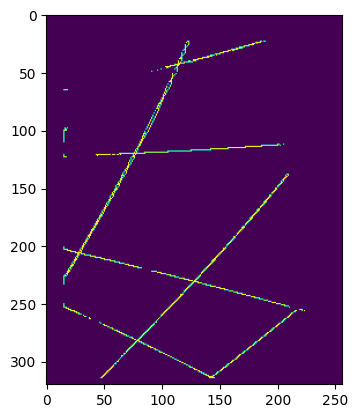

In [12]:
plt.imshow(satellite_data_mask)
plt.show()

In [13]:
dataset_valid = NpyImageDataset(
    folder="/mnt/sciml/a.sadreev/sea_ice_data/valid",
    transform=lambda x: channel_normalize(x, channel_mean=channel_mean, channel_std=channel_std),
    preload = False,
    mmap_mode = 'r'
)

In [14]:
N_conditional_samples = 18
valid_examples = torch.stack([dataset_valid[i*(len(dataset_valid)//N_conditional_samples)] for i in range(N_conditional_samples)])
valid_examples = channel_denormalize(valid_examples, channel_mean=channel_mean, channel_std=channel_std)

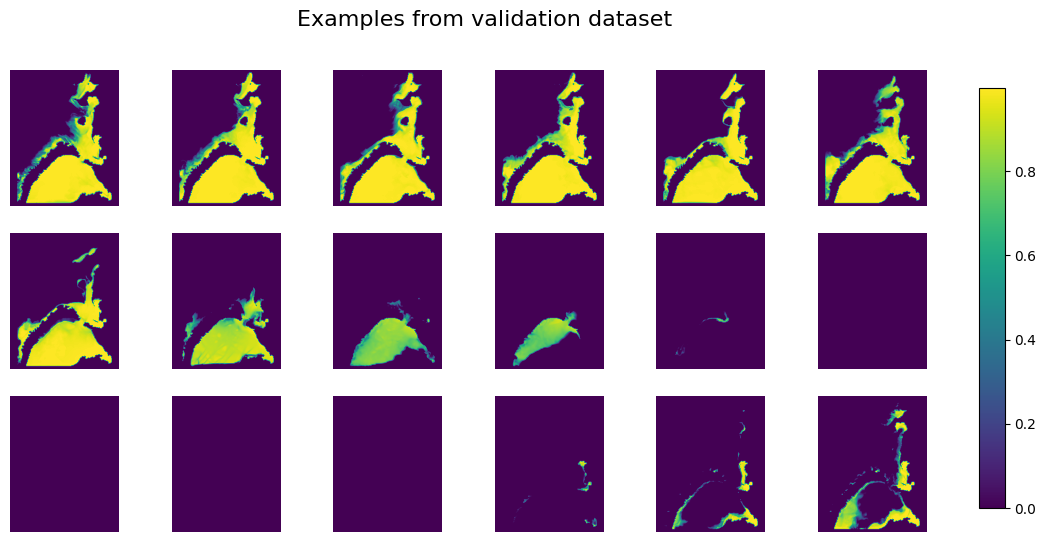

In [15]:
rows, cols = 3, 6
n = rows * cols

imgs = [valid_examples[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2))
axes = axes.flatten()
fig.suptitle("Examples from validation dataset", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis') 
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.85) 
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
plt.show()

In [16]:
satellite_data_mask = satellite_data_mask.reshape((1, 1, 320, 256))

In [17]:
satellite_data_mask_tensor = torch.from_numpy(satellite_data_mask)
print(satellite_data_mask_tensor.shape)
print(satellite_data_mask_tensor.dtype)
print(satellite_data_mask_tensor.device)

torch.Size([1, 1, 320, 256])
torch.int64
cpu


In [18]:
valid_examples_masked = valid_examples*satellite_data_mask_tensor

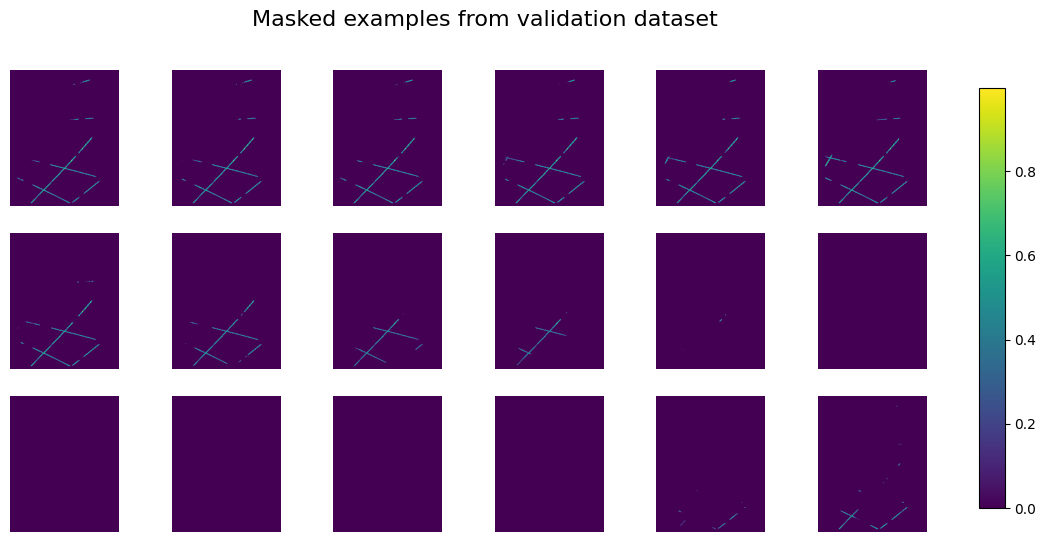

In [19]:
rows, cols = 3, 6
n = rows * cols

imgs = [valid_examples_masked[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2))
axes = axes.flatten()
fig.suptitle("Masked examples from validation dataset", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis') 
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.85) 
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
plt.show()

In [20]:
conditioned_samples = sampler.sample_with_condition(channel_normalize(valid_examples_masked, channel_mean=channel_mean, channel_std=channel_std), satellite_data_mask_tensor, num_timesteps=100, guidance_scale=300, batch_size=18)
conditioned_samples = channel_denormalize(conditioned_samples, channel_mean=channel_mean, channel_std=channel_std)

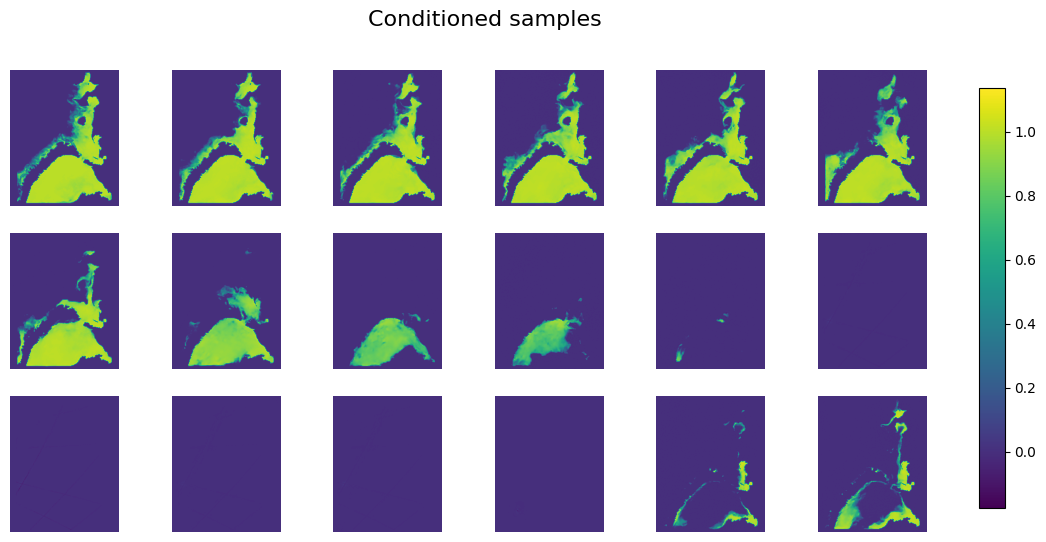

In [38]:
rows, cols = 3, 6
n = rows * cols

imgs = [conditioned_samples[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2))
axes = axes.flatten()
fig.suptitle("Conditioned samples", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis') 
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.85) 
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
plt.show()

In [22]:
conditioned_samples_delta = conditioned_samples.detach().cpu() - valid_examples

In [23]:
data_example = np.load(r"/mnt/sciml/data_assimilation/da_arctic_2015-2024_v0.1/preds/ocean+atmosphere_24_2015-01-17.npy")

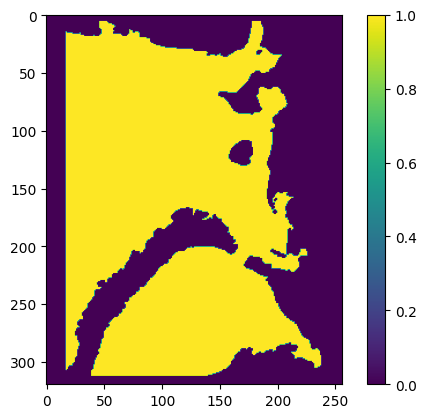

In [24]:
water_mask_initial = np.where(np.isnan(data_example[7, 0, :, :]), 0, 1)
water_mask = np.pad(water_mask_initial, ((4, 5), (15, 16)))
plt.imshow(water_mask)
plt.colorbar()
plt.show()

In [25]:
water_to_land_ratio = np.mean(water_mask)
print(water_to_land_ratio)

0.56600341796875


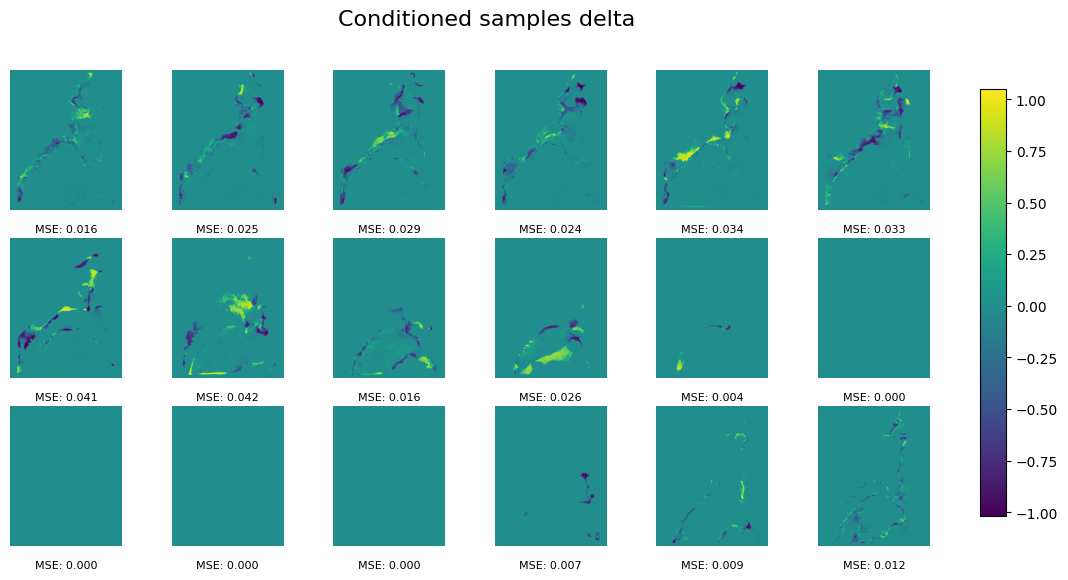

In [26]:
rows, cols = 3, 6
n = rows * cols

imgs = [conditioned_samples_delta[i][0] for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2 + 0.1))
axes = axes.flatten()
fig.suptitle("Conditioned samples delta", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis')
    ax.axis('off')

    mean_square = np.mean(img**2)/water_to_land_ratio
    ax.text(0.5, -0.1, f'MSE: {mean_square:.3f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=8)
    
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
fig.subplots_adjust(right=0.85, bottom=0.1)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)

plt.show()

## Conditioning with background state

In [27]:
N_conditional_samples = 18
background_valid_examples = torch.stack([dataset_valid[i*(len(dataset_valid)//N_conditional_samples) + 480] for i in range(N_conditional_samples)])
background_valid_examples = channel_denormalize(background_valid_examples, channel_mean=channel_mean, channel_std=channel_std)

In [28]:
original_background_delta = valid_examples - background_valid_examples

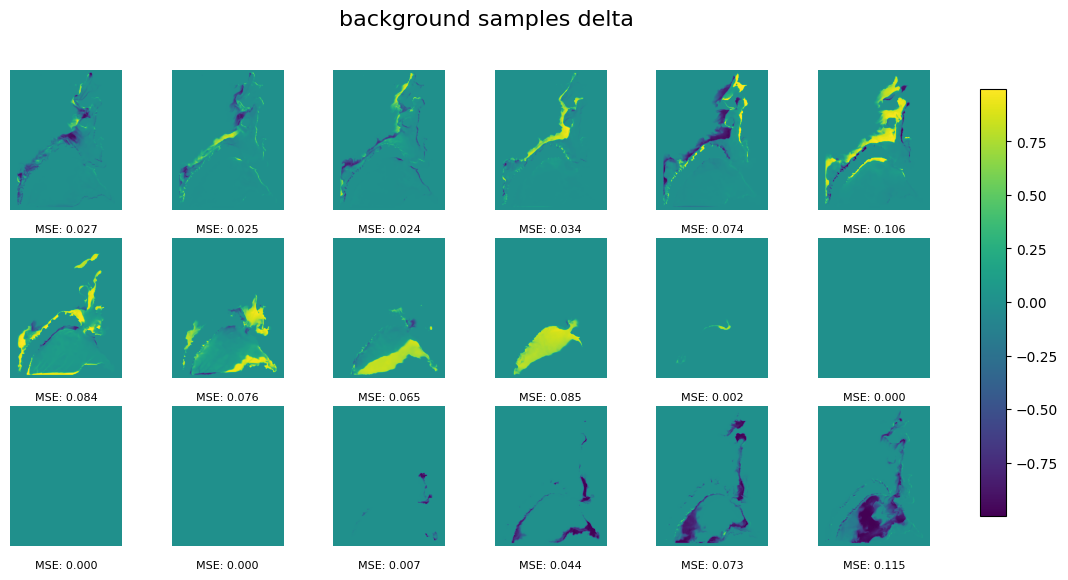

In [34]:
rows, cols = 3, 6
n = rows * cols

imgs = [original_background_delta[i][0] for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2 + 0.1))
axes = axes.flatten()
fig.suptitle("background samples delta", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis')
    ax.axis('off')

    mean_square = np.mean(img**2)/water_to_land_ratio
    ax.text(0.5, -0.1, f'MSE: {mean_square:.3f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=8)
    
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
fig.subplots_adjust(right=0.85, bottom=0.1)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)

plt.show()

In [37]:
conditioned_samples_with_background = sampler.correct_with_condition(background=channel_normalize(background_valid_examples, channel_mean=channel_mean, channel_std=channel_std),
                                                                      y=channel_normalize(valid_examples_masked, channel_mean=channel_mean, channel_std=channel_std), 
                                                                      mask=satellite_data_mask_tensor, 
                                                                      num_timesteps=100,
                                                                      guidance_scale=300,
                                                                      batch_size=18,
                                                                      noise_val=0.9)

conditioned_samples_with_background = channel_denormalize(conditioned_samples_with_background, channel_mean=channel_mean, channel_std=channel_std)

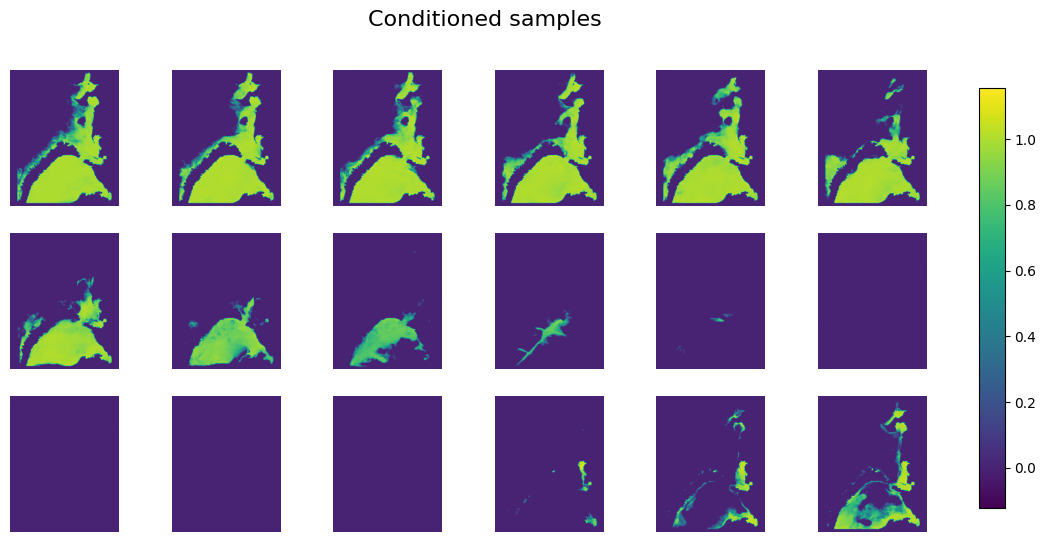

In [39]:
rows, cols = 3, 6
n = rows * cols

imgs = [conditioned_samples_with_background[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2))
axes = axes.flatten()
fig.suptitle("Conditioned samples", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis') 
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.85) 
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
plt.show()

In [41]:
conditioned_samples_with_background_delta = conditioned_samples_with_background.detach().cpu() - valid_examples

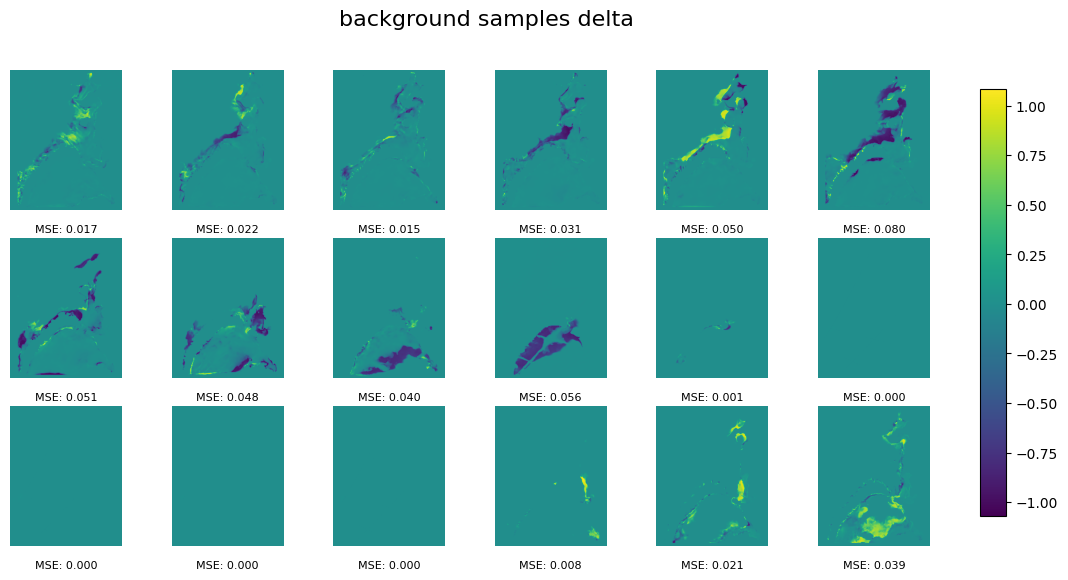

In [42]:
rows, cols = 3, 6
n = rows * cols

imgs = [conditioned_samples_with_background_delta[i][0] for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2 + 0.1))
axes = axes.flatten()
fig.suptitle("background samples delta", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis')
    ax.axis('off')

    mean_square = np.mean(img**2)/water_to_land_ratio
    ax.text(0.5, -0.1, f'MSE: {mean_square:.3f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=8)
    
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
fig.subplots_adjust(right=0.85, bottom=0.1)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)

plt.show()

## Thickness from concentration

In [43]:
only_concentration_mask =  torch.ones(1, 2, 320, 256)
only_concentration_mask[:, 1, :, :] = 0

In [48]:
valid_examples_masked_conc = channel_normalize(valid_examples, channel_mean=channel_mean, channel_std=channel_std)*only_concentration_mask

In [ ]:
plt.imshow(valid_examples)
plt.show()

In [76]:
conentration_to_thickness = sampler.sample_with_condition(y=valid_examples_masked_conc,
                                                          mask=only_concentration_mask,
                                                          num_timesteps=100,
                                                          guidance_scale=1000, 
                                                          batch_size=18)
conentration_to_thickness = channel_denormalize(conentration_to_thickness, channel_mean=channel_mean, channel_std=channel_std)

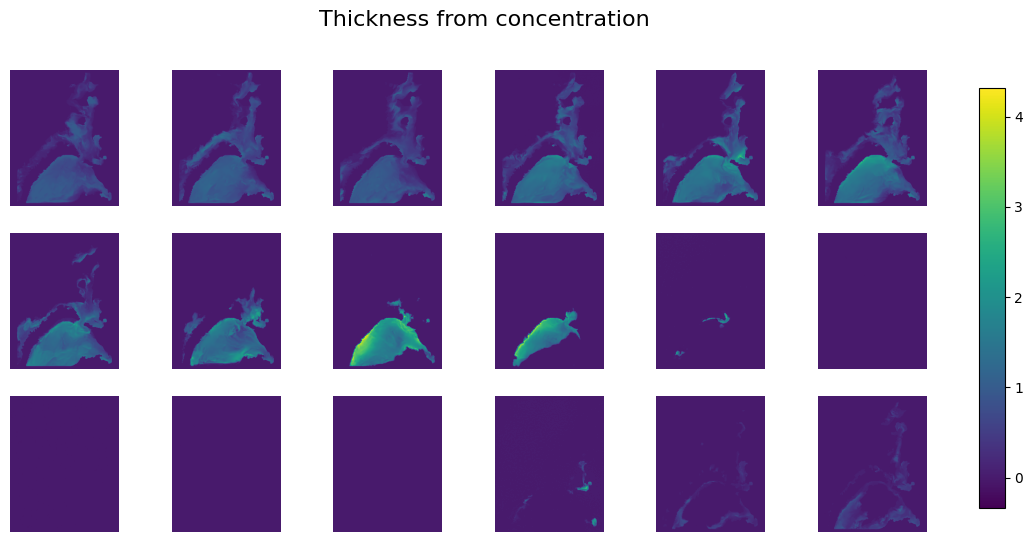

In [77]:
rows, cols = 3, 6
n = rows * cols

imgs = [conentration_to_thickness[i][1].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2))
axes = axes.flatten()
fig.suptitle("Thickness from concentration", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis') 
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.85) 
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
plt.show()

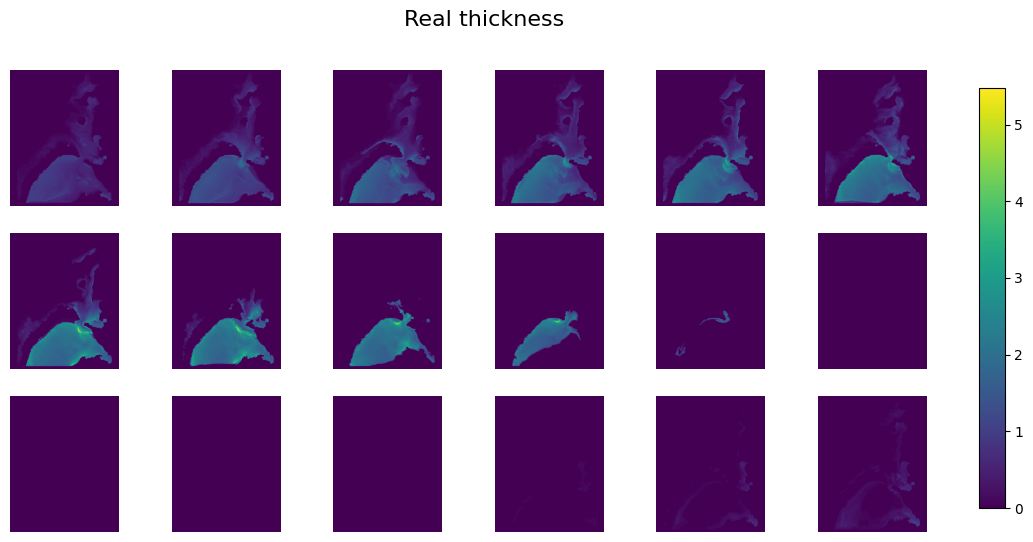

In [78]:
rows, cols = 3, 6
n = rows * cols

imgs = [valid_examples[i][1].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2))
axes = axes.flatten()
fig.suptitle("Real thickness", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis') 
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.85) 
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
plt.show()

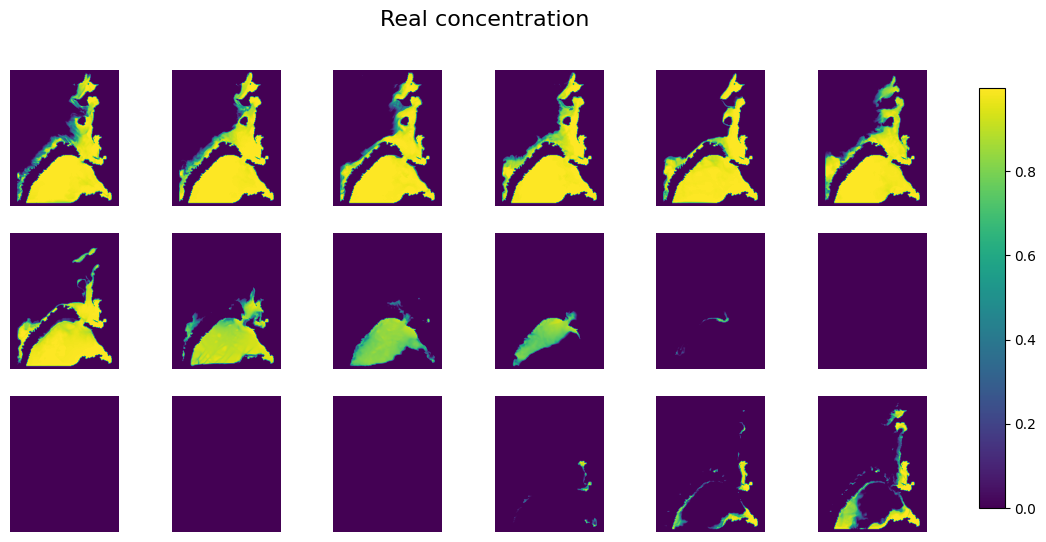

In [79]:
rows, cols = 3, 6
n = rows * cols

imgs = [valid_examples[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2))
axes = axes.flatten()
fig.suptitle("Real concentration", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis') 
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.85) 
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
plt.show()

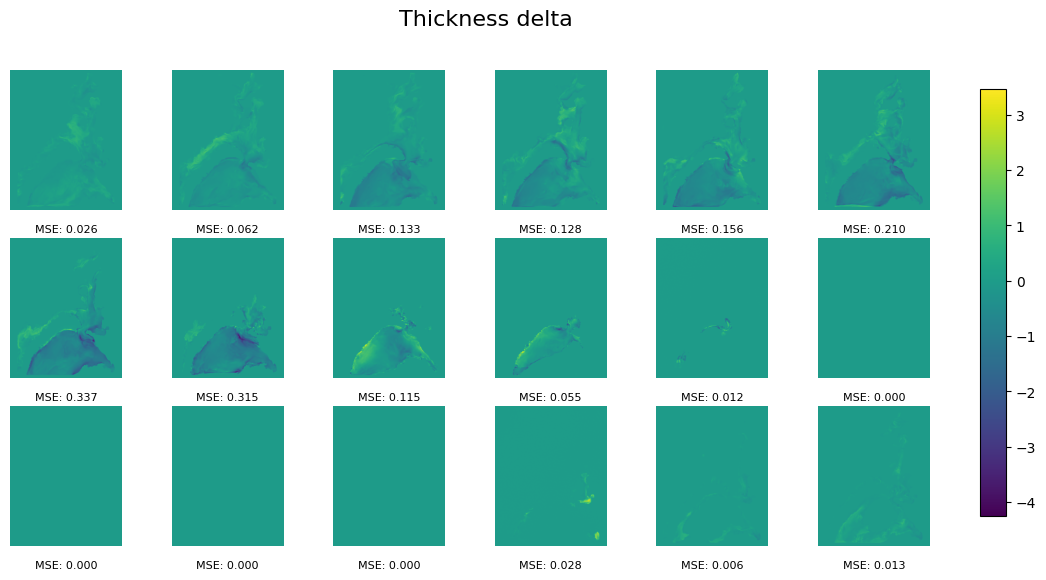

In [80]:
rows, cols = 3, 6
n = rows * cols

imgs = [(conentration_to_thickness.detach().cpu() - valid_examples)[i][1] for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2 + 1, rows*2 + 0.1))
axes = axes.flatten()
fig.suptitle("Thickness delta", fontsize=16, y=0.98)

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm, cmap='viridis')
    ax.axis('off')

    mean_square = np.mean(img**2)/water_to_land_ratio
    ax.text(0.5, -0.1, f'MSE: {mean_square:.3f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=8)
    
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
fig.subplots_adjust(right=0.85, bottom=0.1)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)

plt.show()